In [3]:
import pandas as pd

df = pd.read_csv(
    "../data/World-happiness-report-updated_2024.csv",
    encoding="latin1"
)

print(df.shape)
print(df.head())

(2363, 11)
  Country name  year  Life Ladder  Log GDP per capita  Social support  \
0  Afghanistan  2008        3.724               7.350           0.451   
1  Afghanistan  2009        4.402               7.509           0.552   
2  Afghanistan  2010        4.758               7.614           0.539   
3  Afghanistan  2011        3.832               7.581           0.521   
4  Afghanistan  2012        3.783               7.661           0.521   

   Healthy life expectancy at birth  Freedom to make life choices  Generosity  \
0                              50.5                         0.718       0.164   
1                              50.8                         0.679       0.187   
2                              51.1                         0.600       0.118   
3                              51.4                         0.496       0.160   
4                              51.7                         0.531       0.234   

   Perceptions of corruption  Positive affect  Negative affect 

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2363 non-null   str    
 1   year                              2363 non-null   int64  
 2   Life Ladder                       2363 non-null   float64
 3   Log GDP per capita                2335 non-null   float64
 4   Social support                    2350 non-null   float64
 5   Healthy life expectancy at birth  2300 non-null   float64
 6   Freedom to make life choices      2327 non-null   float64
 7   Generosity                        2282 non-null   float64
 8   Perceptions of corruption         2238 non-null   float64
 9   Positive affect                   2339 non-null   float64
 10  Negative affect                   2347 non-null   float64
dtypes: float64(9), int64(1), str(1)
memory usage: 222.3 KB
None


In [5]:
print(df.isnull().sum())

Country name                          0
year                                  0
Life Ladder                           0
Log GDP per capita                   28
Social support                       13
Healthy life expectancy at birth     63
Freedom to make life choices         36
Generosity                           81
Perceptions of corruption           125
Positive affect                      24
Negative affect                      16
dtype: int64


In [6]:
print(df.describe())

              year  Life Ladder  Log GDP per capita  Social support  \
count  2363.000000  2363.000000         2335.000000     2350.000000   
mean   2014.763860     5.483566            9.399671        0.809369   
std       5.059436     1.125522            1.152069        0.121212   
min    2005.000000     1.281000            5.527000        0.228000   
25%    2011.000000     4.647000            8.506500        0.744000   
50%    2015.000000     5.449000            9.503000        0.834500   
75%    2019.000000     6.323500           10.392500        0.904000   
max    2023.000000     8.019000           11.676000        0.987000   

       Healthy life expectancy at birth  Freedom to make life choices  \
count                       2300.000000                   2327.000000   
mean                          63.401828                      0.750282   
std                            6.842644                      0.139357   
min                            6.720000                      0.22800

In [7]:
print("Countries:", df["Country name"].nunique())
print("Years:", sorted(df["year"].unique()))

Countries: 165
Years: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [8]:
latest_year = df["year"].max()

latest_df = df[df["year"] == latest_year]

top10 = latest_df.sort_values(
    by="Life Ladder",
    ascending=False
).head(10)

print(top10[["Country name", "Life Ladder"]])

     Country name  Life Ladder
680       Finland        7.699
886       Iceland        7.562
556       Denmark        7.504
490    Costa Rica        7.384
1498  Netherlands        7.255
1594       Norway        7.249
2004       Sweden        7.161
1129       Kuwait        7.130
97      Australia        7.025
1249   Luxembourg        7.016


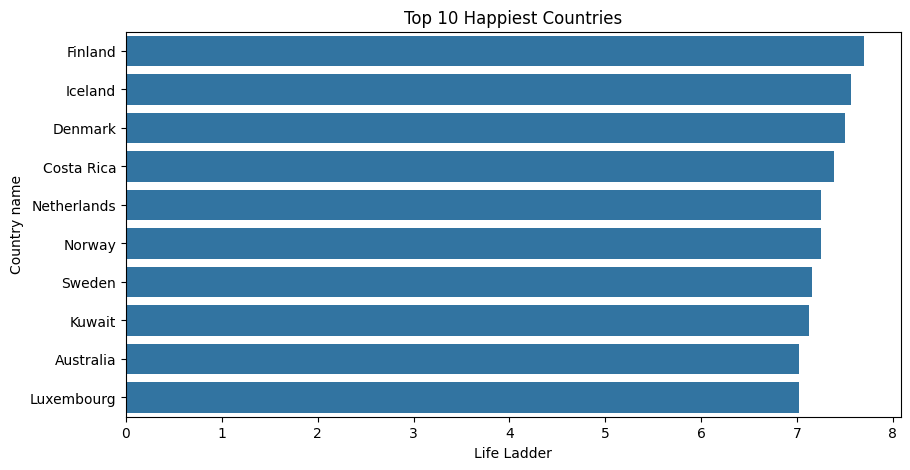

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x="Life Ladder",
    y="Country name"
)

plt.title("Top 10 Happiest Countries")
plt.show()

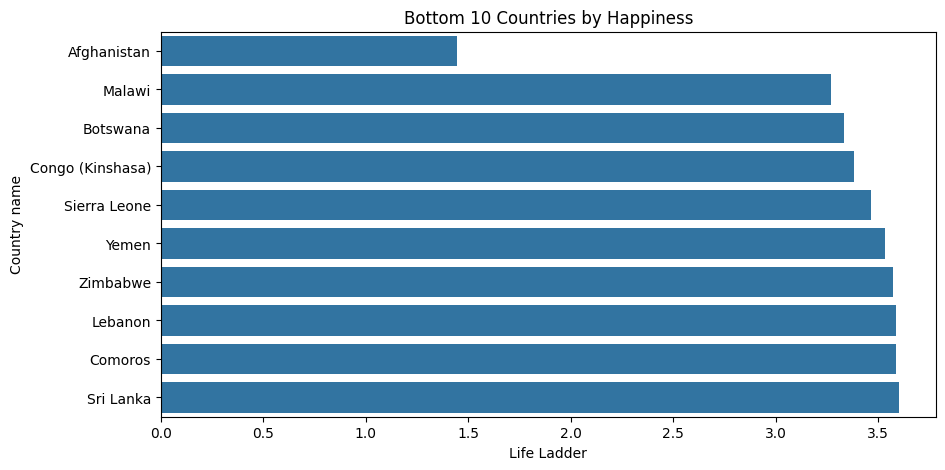

In [10]:
bottom10 = latest_df.sort_values(
    by="Life Ladder"
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=bottom10,
    x="Life Ladder",
    y="Country name"
)

plt.title("Bottom 10 Countries by Happiness")
plt.show()

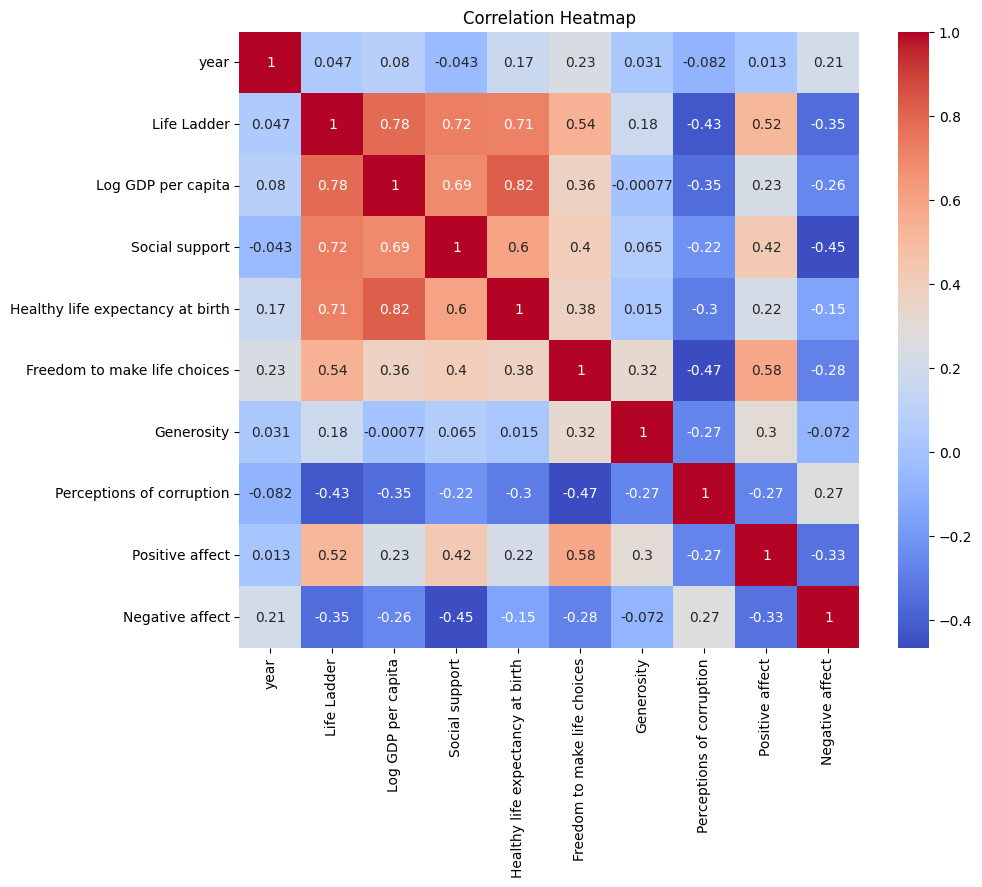

In [11]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

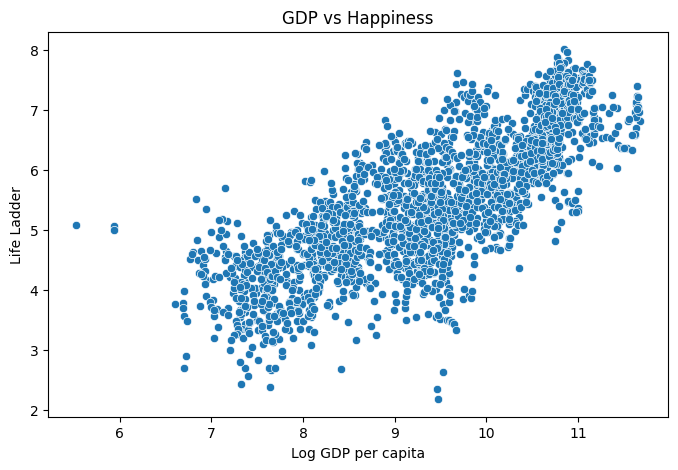

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Log GDP per capita",
    y="Life Ladder"
)

plt.title("GDP vs Happiness")
plt.show()

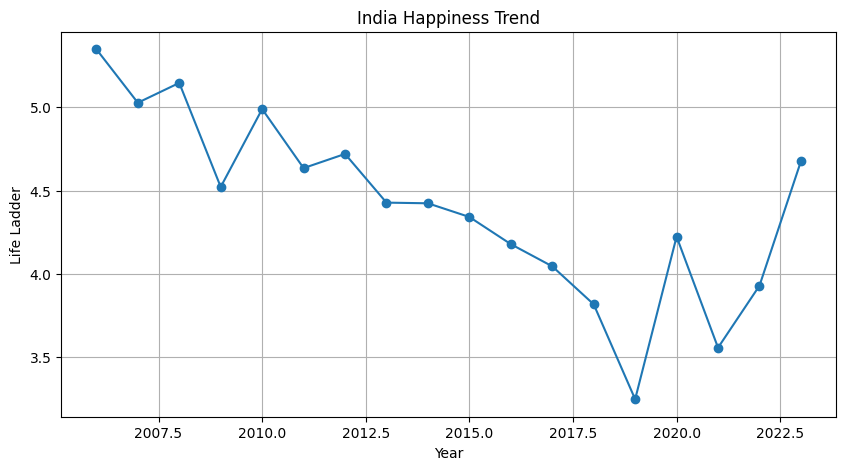

In [13]:
india = df[df["Country name"] == "India"]

plt.figure(figsize=(10,5))

plt.plot(
    india["year"],
    india["Life Ladder"],
    marker="o"
)

plt.title("India Happiness Trend")
plt.xlabel("Year")
plt.ylabel("Life Ladder")

plt.grid(True)

plt.show()

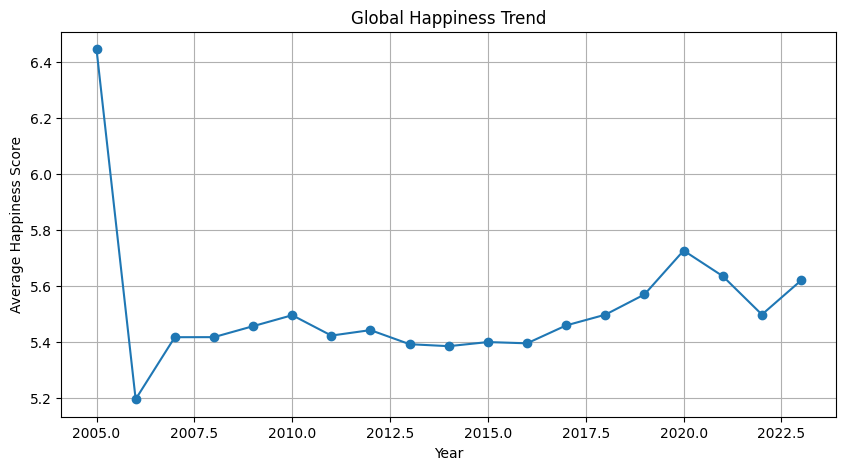

In [14]:
global_trend = (
    df.groupby("year")["Life Ladder"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    global_trend["year"],
    global_trend["Life Ladder"],
    marker="o"
)

plt.title("Global Happiness Trend")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")

plt.grid(True)

plt.show()